# CMPT 742 - Fall 2026
# Assignment 1, Part 1: Image reconstruction (tutorial)

__content creator:__ Yalda

This notebook walks through the ideas you need for Part 1 using small toy examples.
It does **not** solve the assignment for you.

1. The idea
2. Warm-up in 1D
3. Turning a 2D image into a 1D vector
4. Three kinds of pixels
5. A 3×3 image by hand

We only use **numpy** and **matplotlib**.

### What you need to run this notebook
Only **Python 3** with **numpy** and **matplotlib**. No data files, no GPU.

- **Google Colab (easiest):** go to [colab.research.google.com](https://colab.research.google.com), choose *File → Upload notebook*, and pick this file. Nothing to install: numpy and matplotlib are already there.
- **Your own computer:** install the two libraries, then open the notebook in Jupyter or VS Code:
  ```
  pip install numpy matplotlib jupyter
  jupyter notebook
  ```

The same setup works for the Part 2 tutorial.

### How this notebook works
You write most of the code yourself. Each **TODO** (and each extra **Task**) has:
1. a cell for **your code**: replace the `...`,
2. a hidden **Solution** cell right below it. Try it yourself first!
3. a cell that **checks** your answer: look for `correct: True`.

Run the cells in order. If you get stuck, run the Solution cell and move on.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)   # print numbers with 2 decimals

### Plot helpers
Run this cell. It defines two small functions that draw our plots **with the numbers written on them** and a grid,
so you can read every value. You don't need to change it.

In [ ]:
def number_text(x):
    """Short text for a number: 3.0 -> '3', 0.25 -> '0.25', -0.0000001 -> '0'."""
    x = round(float(x), 2) + 0.0      # + 0.0 turns -0.0 into 0.0
    return f'{x:g}'


def plot_1d(signals, labels, title):
    """Plot 1D signals with every value written on its point, whole-number ticks and a grid."""
    plt.figure(figsize=(8, 4))
    for values, label in zip(signals, labels):
        line = plt.plot(values, 'o-', label=label)[0]
        for i in range(len(values)):
            plt.text(i, values[i] + 0.3, number_text(values[i]), color=line.get_color(), ha='center')
    all_values = np.concatenate(signals)
    plt.xticks(range(len(signals[0])))
    plt.yticks(range(int(np.floor(all_values.min())) - 1, int(np.ceil(all_values.max())) + 2))
    plt.grid(True)
    plt.xlabel('position i')
    plt.ylabel('value')
    plt.title(title)
    plt.legend()
    plt.show()


def show_image(ax, img, title, vmin=0, vmax=1, cmap='gray', write_values=True, hide_zeros=False):
    """Show a small image with its value written on every pixel and a grid between pixels."""
    h, w = img.shape
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    if h > 10 or w > 10:              # too big to write every value
        ax.axis('off')
        return
    ax.set_xticks(range(w))           # column numbers
    ax.set_yticks(range(h))           # row numbers
    ax.set_xticks(np.arange(-0.5, w), minor=True)
    ax.set_yticks(np.arange(-0.5, h), minor=True)
    ax.grid(which='minor', color='gray', linewidth=1)
    ax.tick_params(which='minor', length=0)
    if write_values:
        for i in range(h):
            for j in range(w):
                if hide_zeros and img[i, j] == 0:
                    continue
                dark_pixel = cmap == 'gray' and img[i, j] < (vmin + vmax) / 2
                ax.text(j, i, number_text(img[i, j]), ha='center', va='center',
                        color='white' if dark_pixel else 'black')

# 1. The idea

We have an image **S**. We keep only:
- its **second derivatives** at every pixel (how different each pixel is from its neighbours), and
- the values of its **4 corner pixels**.

Then we throw S away and ask: *can we get the image back?*
Yes, by solving a linear system **Av = b**.

| Symbol | What it is | Where it comes from |
|---|---|---|
| S | the input image | known: one of the images in `Reconstruction/` |
| V | the image we rebuild | **unknown**, we solve for it |
| b | second derivatives of S (+ the 4 corner values) | computed from S |
| A | the coefficients of the equations | depends only on the image **size** |

**Note:** the four files in `Reconstruction/` (`large.jpg`, `large1.jpg`, `target.jpg`, `target1.jpg`) are separate test inputs.
Each one is used as S on its own. `target.jpg` is *not* the target image V.

# 2. Warm-up in 1D

Before images, let's do the same thing with a list of numbers (think of it as one row of an image).

The second derivative at position `i` is:

$$2s[i] - s[i-1] - s[i+1]$$

The first and last positions don't have both neighbours, so instead we **fix** their values.

In [ ]:
s1 = np.array([3.0, 5.0, 4.0, 8.0, 7.0, 9.0])   # "1" = 1D
n = len(s1)

plot_1d([s1], ['s1'], 'Our 1D "image" s1')

### Step 1: compute b

Fill `b1`:
- for the middle positions (`1` to `n-2`): the second derivative `2*s1[i] - s1[i-1] - s1[i+1]`
- for the first and last positions: just the value of `s1` there (these are the fixed values)

In [ ]:
b1 = np.zeros(n)

# TODO: loop over the middle positions and compute the second derivative
...

# TODO: set the two fixed values at the start and the end
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
b1 = np.zeros(n)

for i in range(1, n - 1):            # skip the first and last positions
    b1[i] = 2 * s1[i] - s1[i - 1] - s1[i + 1]

b1[0] = s1[0]                        # fixed value at the start
b1[n - 1] = s1[n - 1]                # fixed value at the end

In [ ]:
# run this cell to check your code
print('b1 =', b1)
print('correct:', np.allclose(b1, [3, 3, -5, 5, -3, 9]))

### Step 2: build A

Each **row** of A holds the coefficients of **one equation**.
For position `i` the equation is `2v[i] - v[i-1] - v[i+1] = b[i]`,
so row `i` has `2` in column `i` and `-1` in columns `i-1` and `i+1`.

For the first and last rows the equation is just `v[0] = b[0]` and `v[n-1] = b[n-1]`, so put a `1` on the diagonal.

In [ ]:
A1 = np.zeros((n, n))

# TODO: fill the middle rows (2 on the diagonal, -1 left and right of it)
...

# TODO: fill the first and last rows
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
A1 = np.zeros((n, n))

for i in range(1, n - 1):
    A1[i, i] = 2
    A1[i, i - 1] = -1
    A1[i, i + 1] = -1

A1[0, 0] = 1                         # equation: v[0] = b[0]
A1[n - 1, n - 1] = 1                 # equation: v[n-1] = b[n-1]

In [ ]:
# run this cell to check your code
print(A1)

# if A1 is right, multiplying it with s1 gives back b1
print('correct:', np.allclose(A1 @ s1, b1) and np.count_nonzero(A1) == 3 * (n - 2) + 2)

Notice: A only contains `2`, `-1` and `1`. **It has no values from s1 in it.**
All the information about s1 is in b.

### Step 3: solve

Solve `A1 v1 = b1` with `np.linalg.solve`.

In [ ]:
# TODO: solve the system and store the answer in v1
v1 = ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
v1 = np.linalg.solve(A1, b1)

In [ ]:
# run this cell to check your code
print('s1 =', s1)
print('v1 =', v1)
print('error |Av - b| =', np.linalg.norm(A1 @ v1 - b1))
print('correct:', np.allclose(v1, s1))

`v1` is exactly `s1`: we rebuilt the signal from its second derivatives and the two end values.

### Step 4: experiment, change the end values

Make a copy of `b1` called `b1_new`. Make the start **3 higher** and the end **2 lower** than in `s1`, then solve again.

In [ ]:
b1_new = b1.copy()

# TODO: change the first and last entries of b1_new
...

# TODO: solve again and store the answer in v1_new
v1_new = ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
b1_new = b1.copy()

b1_new[0] = s1[0] + 3                # start 3 higher
b1_new[n - 1] = s1[n - 1] - 2        # end 2 lower

v1_new = np.linalg.solve(A1, b1_new)

In [ ]:
# run this cell to see the result
plot_1d([s1, v1_new, v1_new - s1],
        ['original s1', 'v1 with new end values', 'difference'],
        'Step 4: new end values')

All the ups and downs are kept, but a **straight line** is added.

Why? We only changed the **two end values** of b. The **middle** of b (the second derivatives) stayed the same.
A straight line has zero second derivative (it doesn't bend), so adding it keeps the middle of b the same.
The solver keeps all the bends of `s1` and adds the straight line that connects the new end values.

### Task 1
Change **only the two end values** so that the result is the original signal shifted up by 2 everywhere
(`v1_task` should equal `s1 + 2`).

In [ ]:
b1_task = b1.copy()

# change the two end values of b1_task
...

v1_task = np.linalg.solve(A1, b1_task)

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
b1_task = b1.copy()

b1_task[0] = s1[0] + 2               # both ends move up by the same amount
b1_task[n - 1] = s1[n - 1] + 2

v1_task = np.linalg.solve(A1, b1_task)

In [ ]:
# run this cell to check your code
print('v1_task - s1 =', v1_task - s1)
print('correct:', np.allclose(v1_task, s1 + 2))

When both ends move by the same amount, the added "straight line" is flat, so the whole signal just shifts.

# 3. Turning a 2D image into a 1D vector

In 2D, the unknowns are all the pixels of V. A solver needs them in **one long vector**,
so we number the pixels row by row:

$$\text{pixel } (i, j) \rightarrow k = i \cdot w + j \qquad (i = \text{row},\ j = \text{column},\ w = \text{width})$$

In [ ]:
h, w = 3, 4
img = np.arange(h * w).reshape(h, w)

print('image (each pixel shows its number k):')
print(img)
print('flattened:', img.flatten())

Write a function `pixel_index(i, j, w)` that returns `k` for pixel `(i, j)`.

In [ ]:
def pixel_index(i, j, w):
    """Position of pixel (row i, column j) in the flattened vector."""
    # TODO: return k
    ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
def pixel_index(i, j, w):
    """Position of pixel (row i, column j) in the flattened vector."""
    return i * w + j

In [ ]:
# run this cell to check your code
i, j = 1, 2
k = pixel_index(i, j, w)
print('pixel', (i, j), '-> k =', k)
print('img[i, j] =', img[i, j], '   img.flatten()[k] =', img.flatten()[k])

all_correct = True
for i in range(h):
    for j in range(w):
        if img.flatten()[pixel_index(i, j, w)] != img[i, j]:
            all_correct = False
print('correct:', all_correct)

To go back from the vector to an image, use `reshape`: `v.reshape(h, w)`.

### Task 2
Write the opposite of `pixel_index`: given `k` and the width `w`, return the pixel `(i, j)`.

__hint__: use integer division `//` and remainder `%`.

In [ ]:
def pixel_position(k, w):
    """Which pixel (row i, column j) is entry k of the flattened vector?"""
    ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
def pixel_position(k, w):
    """Which pixel (row i, column j) is entry k of the flattened vector?"""
    i = k // w                       # number of full rows before k
    j = k % w                        # what is left over is the column
    return i, j

In [ ]:
# run this cell to check your code
h, w = 3, 4
all_correct = True
for i in range(h):
    for j in range(w):
        if pixel_position(pixel_index(i, j, w), w) != (i, j):
            all_correct = False
print('correct:', all_correct)

# 4. Three kinds of pixels

Every pixel gets one equation. What the equation looks like depends on which neighbours exist:

| Pixel type | Neighbours | Equation |
|---|---|---|
| **Interior** | all 4 | `4v - left - right - up - down` = (same thing on s) |
| **Edge** | one direction is missing | keep only the direction that has **both** neighbours, e.g. top edge: `2v - left - right` = (same on s) |
| **Corner** | both directions missing | would be `0 = 0`, so use **`v = c`** instead |

### Task 3
Write a function that returns `'corner'`, `'edge'` or `'interior'` for pixel `(i, j)` in an `h × w` image.

__hint__: a pixel has a left AND a right neighbour when `0 < j < w - 1`. What about up and down?

In [ ]:
def get_pixel_type(i, j, h, w):
    has_left_and_right = ...
    has_up_and_down = ...
    ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
def get_pixel_type(i, j, h, w):
    has_left_and_right = 0 < j < w - 1
    has_up_and_down = 0 < i < h - 1
    if has_left_and_right and has_up_and_down:
        return 'interior'
    if has_left_and_right or has_up_and_down:
        return 'edge'
    return 'corner'

In [ ]:
# run this cell to check your code
h, w = 6, 6
names = ['interior', 'edge', 'corner']
pixel_type = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        pixel_type[i, j] = names.index(get_pixel_type(i, j, h, w))

fig, ax = plt.subplots()
show_image(ax, pixel_type, 'Pixel types in a 6x6 image (I, E, C)', vmin=0, vmax=2, cmap='Pastel1', write_values=False)
for i in range(h):
    for j in range(w):
        ax.text(j, i, names[int(pixel_type[i, j])][0].upper(), ha='center', va='center')
plt.show()

# a 6x6 image has 4 corners, 16 edge pixels and 16 interior pixels
print('corners: ', np.sum(pixel_type == 2), '(should be 4)')
print('edges:   ', np.sum(pixel_type == 1), '(should be 16)')
print('interior:', np.sum(pixel_type == 0), '(should be 16)')

# 5. A 3×3 image by hand

Now a real (tiny) image. The pixels are numbered:
```
 0  1  2
 3  4  5
 6  7  8
```
9 pixels → 9 equations → A is 9×9. We write every row by hand.

In [ ]:
s = np.array([[0.2, 0.4, 0.3],
              [0.5, 0.9, 0.6],
              [0.1, 0.7, 0.8]])
h, w = s.shape

fig, ax = plt.subplots()
show_image(ax, s, 'S (3x3)')
plt.show()

### Step 1: compute b

`b` has one entry per pixel: the second derivative of `s` at that pixel (or the corner value for corners).
The corners and the top edge are done for you as examples. **Fill in the other entries.**

In [ ]:
b = np.zeros(9)

# Corners (pixels 0, 2, 6, 8): the corner value of s
b[0] = s[0, 0]
b[2] = s[0, 2]
b[6] = s[2, 0]
b[8] = s[2, 2]

# Top edge, pixel 1 = (0,1): only left-right
b[1] = 2 * s[0, 1] - s[0, 0] - s[0, 2]

# TODO: Left edge, pixel 3 = (1,0): only up-down
...

# TODO: Right edge, pixel 5 = (1,2): only up-down
...

# TODO: Bottom edge, pixel 7 = (2,1): only left-right
...

# TODO: Interior, pixel 4 = (1,1): all 4 neighbours
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
b = np.zeros(9)

# Corners (pixels 0, 2, 6, 8): the corner value of s
b[0] = s[0, 0]
b[2] = s[0, 2]
b[6] = s[2, 0]
b[8] = s[2, 2]

# Top edge, pixel 1 = (0,1): only left-right
b[1] = 2 * s[0, 1] - s[0, 0] - s[0, 2]

# Left edge, pixel 3 = (1,0): only up-down
b[3] = 2 * s[1, 0] - s[0, 0] - s[2, 0]

# Right edge, pixel 5 = (1,2): only up-down
b[5] = 2 * s[1, 2] - s[0, 2] - s[2, 2]

# Bottom edge, pixel 7 = (2,1): only left-right
b[7] = 2 * s[2, 1] - s[2, 0] - s[2, 2]

# Interior, pixel 4 = (1,1): all 4 neighbours
b[4] = 4 * s[1, 1] - s[1, 0] - s[1, 2] - s[0, 1] - s[2, 1]

In [ ]:
# run this cell to check your code
print('b =', b)
print('b arranged like the image:')
print(b.reshape(3, 3))
print('correct:', np.allclose(b, [0.2, 0.3, 0.3, 0.7, 1.4, 0.1, 0.1, 0.5, 0.8]))

### Step 2: build A

Row `k` of A holds the coefficients of the equation for pixel `k`. It's the same pattern as b, but with `v` instead of `s`:
for example, pixel 1 has `2v1 - v0 - v2`, so row 1 has `2` in column 1 and `-1` in columns 0 and 2.

The corners and the top edge are done for you again. **Fill in the other rows.**

In [ ]:
A = np.zeros((9, 9))

# Corners (pixels 0, 2, 6, 8): v = corner value
A[0, 0] = 1
A[2, 2] = 1
A[6, 6] = 1
A[8, 8] = 1

# Top edge, pixel 1 = (0,1): only left-right   ->  2v1 - v0 - v2
A[1, 1] = 2
A[1, 0] = -1
A[1, 2] = -1

# TODO: Left edge, pixel 3 = (1,0): only up-down     ->  2v3 - v0 - v6
...

# TODO: Right edge, pixel 5 = (1,2): only up-down    ->  2v5 - v2 - v8
...

# TODO: Bottom edge, pixel 7 = (2,1): only left-right ->  2v7 - v6 - v8
...

# TODO: Interior, pixel 4 = (1,1): all 4 neighbours  ->  4v4 - v3 - v5 - v1 - v7
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
A = np.zeros((9, 9))

# Corners (pixels 0, 2, 6, 8): v = corner value
A[0, 0] = 1
A[2, 2] = 1
A[6, 6] = 1
A[8, 8] = 1

# Top edge, pixel 1 = (0,1): only left-right   ->  2v1 - v0 - v2
A[1, 1] = 2
A[1, 0] = -1
A[1, 2] = -1

# Left edge, pixel 3 = (1,0): only up-down     ->  2v3 - v0 - v6
A[3, 3] = 2
A[3, 0] = -1
A[3, 6] = -1

# Right edge, pixel 5 = (1,2): only up-down    ->  2v5 - v2 - v8
A[5, 5] = 2
A[5, 2] = -1
A[5, 8] = -1

# Bottom edge, pixel 7 = (2,1): only left-right ->  2v7 - v6 - v8
A[7, 7] = 2
A[7, 6] = -1
A[7, 8] = -1

# Interior, pixel 4 = (1,1): all 4 neighbours  ->  4v4 - v3 - v5 - v1 - v7
A[4, 4] = 4
A[4, 3] = -1
A[4, 5] = -1
A[4, 1] = -1
A[4, 7] = -1

In [ ]:
# run this cell to check your code
print('A =')
print(A)

# if A is right, multiplying it with s gives back b (and b is already checked)
print('correct:', np.count_nonzero(A) == 21 and np.allclose(A @ s.flatten(), b))

fig, ax = plt.subplots(figsize=(6, 6))
show_image(ax, A, 'A  (red = positive, blue = negative)', vmin=-4, vmax=4, cmap='bwr', hide_zeros=True)
ax.set_xlabel('column = pixel number')
ax.set_ylabel('row = equation number')
plt.show()

### Step 3: solve and compare

Solve for `v`, then reshape it into a 3×3 image `V`.

In [ ]:
# TODO: solve A v = b
v = ...

# TODO: reshape v into a 3x3 image
V = ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution
v = np.linalg.solve(A, b)
V = v.reshape(h, w)

error |Av - b| = 2.830524433501838e-16
max |V - S|    = 1.1102230246251565e-16
correct: True


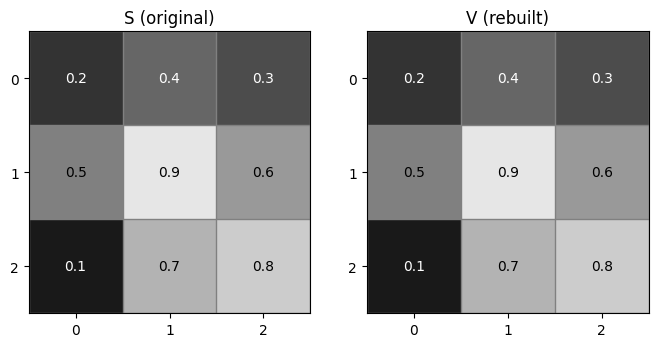

In [64]:
# run this cell to check your code
print('error |Av - b| =', np.linalg.norm(A @ v - b))
print('max |V - S|    =', np.abs(V - s).max())
print('correct:', np.allclose(V, s))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show_image(axes[0], s, 'S (original)')
show_image(axes[1], V, 'V (rebuilt)')
plt.show()